In [ ]:
!pip install shap lime xgboost


In [ ]:
# ============================================
# 1️⃣ IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from lime.lime_tabular import LimeTabularExplainer


In [ ]:
# ============================================
# 2️⃣ LOAD DATASET
# ============================================

data = pd.read_csv("/content/UCI_Credit_Card.csv")

# Drop ID
data = data.drop("ID", axis=1)

# Rename target
data = data.rename(columns={"default.payment.next.month": "Default"})

print("Dataset Shape:", data.shape)
print(data.head())


Dataset Shape: (30000, 24)
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0    20000.0    2          2         1   24      2      2     -1     -1   
1   120000.0    2          2         2   26     -1      2      0      0   
2    90000.0    2          2         2   34      0      0      0      0   
3    50000.0    2          2         1   37      0      0      0      0   
4    50000.0    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1      0  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2      0  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3      0  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4      0  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  Default 

In [ ]:
# ============================================
# 3️⃣ DEFINE FEATURES & TARGET
# ============================================

X = data.drop("Default", axis=1)
y = data["Default"]

feature_names = X.columns

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# ============================================
# 4️⃣ LOGISTIC REGRESSION
# ============================================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("\nLogistic Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))



Logistic Accuracy: 0.8076666666666666
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [ ]:
# ============================================
# 5️⃣ XGBOOST MODEL
# ============================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:28:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.8155
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.65      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.79      6000



In [ ]:
# ============================================
# 6️⃣ HYBRID MODEL (Weighted Ensemble)
# ============================================

log_probs = log_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Adjust weights if needed
hybrid_probs = 0.4 * log_probs + 0.6 * xgb_probs

hybrid_pred = (hybrid_probs > 0.5).astype(int)

print("\nHybrid Accuracy:", accuracy_score(y_test, hybrid_pred))
print(classification_report(y_test, hybrid_pred))



Hybrid Accuracy: 0.8173333333333334
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.68      0.33      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



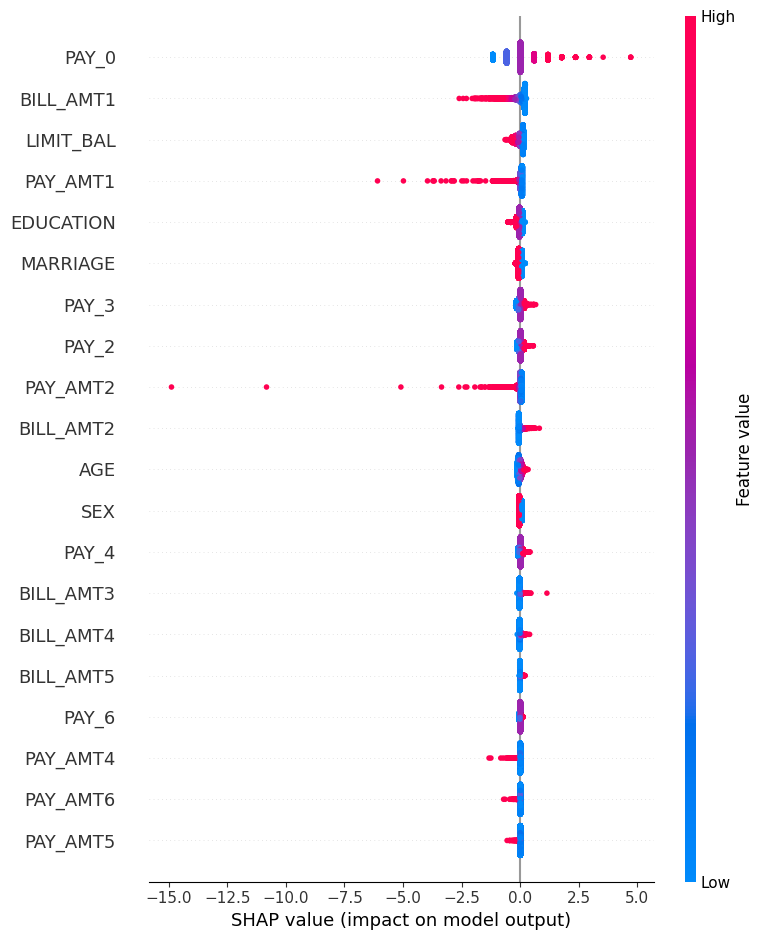

In [ ]:
# ============================================
# 7️⃣ SHAP - LOGISTIC
# ============================================

explainer_log = shap.LinearExplainer(log_model, X_train)
shap_values_log = explainer_log.shap_values(X_test)

shap.summary_plot(
    shap_values_log,
    pd.DataFrame(X_test, columns=feature_names)
)


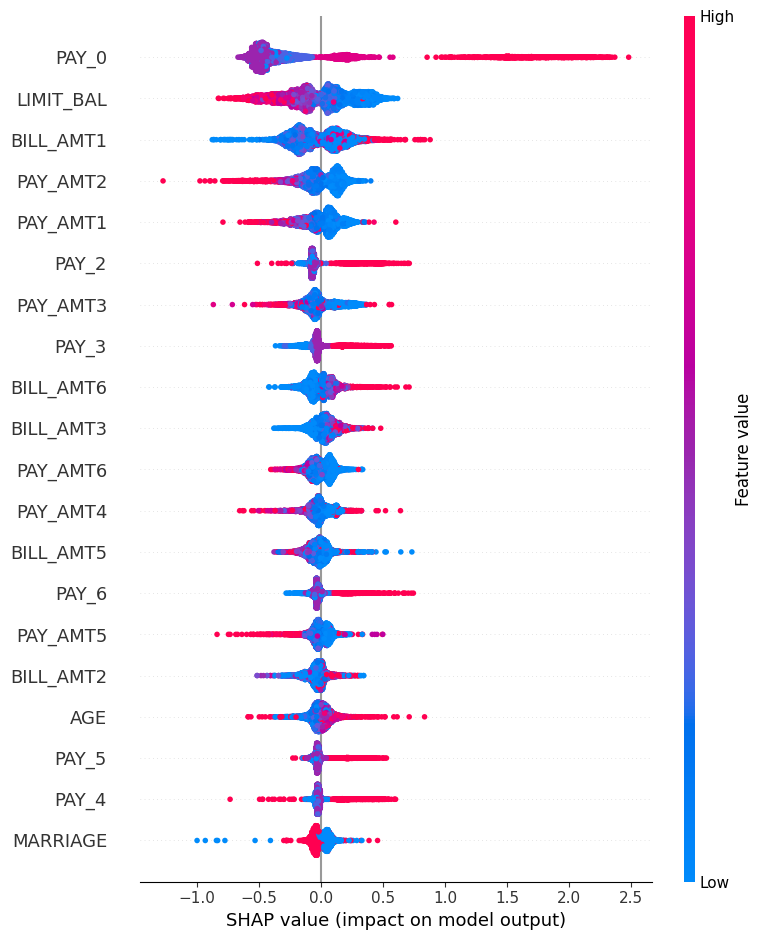

In [ ]:
# ============================================
# 8️⃣ SHAP - XGBOOST
# ============================================

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(
    shap_values_xgb,
    pd.DataFrame(X_test, columns=feature_names)
)


In [ ]:
# ============================================
# 9️⃣ LIME EXPLANATION
# ============================================

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    class_names=["Non-Default", "Default"],
    mode="classification"
)

# Explain one instance
index = 0

lime_exp = lime_explainer.explain_instance(
    X_test_df.iloc[index].values,
    xgb_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)


In [ ]:
# ============================================
# 🔟 GLOBAL FEATURE IMPORTANCE (SHAP)
# ============================================

# Logistic SHAP mean importance
mean_shap_log = np.abs(shap_values_log).mean(axis=0)

log_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": mean_shap_log
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Logistic SHAP Features:")
print(log_importance.head(10))


# XGBoost SHAP mean importance
mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": mean_shap_xgb
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 XGBoost SHAP Features:")
print(xgb_importance.head(10))



Top 10 Logistic SHAP Features:
      Feature  Importance
5       PAY_0    0.436606
11  BILL_AMT1    0.214267
0   LIMIT_BAL    0.110598
17   PAY_AMT1    0.089124
2   EDUCATION    0.077172
3    MARRIAGE    0.070580
7       PAY_3    0.068150
6       PAY_2    0.066048
18   PAY_AMT2    0.064786
12  BILL_AMT2    0.063097

Top 10 XGBoost SHAP Features:
      Feature  Importance
5       PAY_0    0.531851
0   LIMIT_BAL    0.222160
11  BILL_AMT1    0.171006
18   PAY_AMT2    0.133268
17   PAY_AMT1    0.113135
6       PAY_2    0.102931
19   PAY_AMT3    0.102221
7       PAY_3    0.082559
16  BILL_AMT6    0.079067
13  BILL_AMT3    0.073312


In [ ]:
# ============================================
# 1️⃣1️⃣ CROSS-MODEL AGREEMENT (SHAP)
# ============================================

top5_log = set(log_importance.head(5)["Feature"])
top5_xgb = set(xgb_importance.head(5)["Feature"])

overlap = top5_log.intersection(top5_xgb)

agreement_percentage = (len(overlap) / 5) * 100

print("\nTop 5 Logistic:", top5_log)
print("Top 5 XGBoost:", top5_xgb)
print("\nOverlap:", overlap)
print("Agreement %:", agreement_percentage)



Top 5 Logistic: {'BILL_AMT1', 'LIMIT_BAL', 'PAY_0', 'EDUCATION', 'PAY_AMT1'}
Top 5 XGBoost: {'BILL_AMT1', 'LIMIT_BAL', 'PAY_AMT2', 'PAY_0', 'PAY_AMT1'}

Overlap: {'LIMIT_BAL', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1'}
Agreement %: 80.0


In [ ]:
# ============================================
# 1️⃣2️⃣ SHAP vs LIME AGREEMENT (LOCAL)
# ============================================

# Get LIME feature names
lime_features = [feature[0].split(' ')[0] for feature in lime_exp.as_list()[:5]]

# Get SHAP top 5 for same instance (XGBoost)
shap_instance_values = shap_values_xgb[index]
shap_instance_df = pd.DataFrame({
    "Feature": feature_names,
    "Value": np.abs(shap_instance_values)
}).sort_values(by="Value", ascending=False)

shap_top5_instance = set(shap_instance_df.head(5)["Feature"])

lime_top5 = set(lime_features)

local_overlap = shap_top5_instance.intersection(lime_top5)
local_agreement = (len(local_overlap) / 5) * 100

print("\nTop 5 SHAP (Instance):", shap_top5_instance)
print("Top 5 LIME (Instance):", lime_top5)
print("\nLocal Overlap:", local_overlap)
print("Local Agreement %:", local_agreement)



Top 5 SHAP (Instance): {'BILL_AMT1', 'PAY_AMT3', 'LIMIT_BAL', 'PAY_0', 'BILL_AMT3'}
Top 5 LIME (Instance): {'-1.06', 'BILL_AMT1', 'PAY_AMT2', 'LIMIT_BAL', 'PAY_0'}

Local Overlap: {'LIMIT_BAL', 'PAY_0', 'BILL_AMT1'}
Local Agreement %: 60.0


In [ ]:
# ============================================
# 1️⃣3️⃣ COUNTERFACTUAL OPTIMIZATION
# ============================================

# Find an instance predicted as Default (1)
default_indices = np.where(xgb_pred == 1)[0]

print("Number of predicted defaults:", len(default_indices))

# Select first default case
cf_index = default_indices[0]

original = X_test[cf_index].copy()

original_prob = xgb_model.predict_proba([original])[0][1]

print("\nOriginal Default Probability:", original_prob)

# Convert to DataFrame for tracking
original_df = pd.DataFrame([original], columns=feature_names)

# --------------------------------------------
# Define controllable features
# --------------------------------------------

controllable_features = [
    "PAY_0", "PAY_2", "PAY_3",
    "BILL_AMT1", "BILL_AMT2",
    "PAY_AMT1", "PAY_AMT2"
]

# --------------------------------------------
# Gradient-free minimal change search
# --------------------------------------------

counterfactual = original.copy()
step = 0.1
max_iter = 200

for i in range(max_iter):
    prob = xgb_model.predict_proba([counterfactual])[0][1]

    if prob < 0.5:
        break

    # Reduce repayment delay risk features
    for feat in controllable_features:
        if feat in feature_names:
            idx = list(feature_names).index(feat)
            counterfactual[idx] -= step

cf_prob = xgb_model.predict_proba([counterfactual])[0][1]

print("\nCounterfactual Default Probability:", cf_prob)

# --------------------------------------------
# Distance Measurement
# --------------------------------------------

distance = np.linalg.norm(original - counterfactual)

print("\nMinimal Change Distance:", distance)

# Show comparison
cf_df = pd.DataFrame([counterfactual], columns=feature_names)

comparison = pd.concat([original_df, cf_df])
comparison.index = ["Original", "Counterfactual"]

comparison.head(10)


Number of predicted defaults: 736

Original Default Probability: 0.8147488

Counterfactual Default Probability: 0.4313154

Minimal Change Distance: 0.2645751311064592


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
Original,0.251994,-1.23695,-1.077532,-1.059367,-0.699574,0.902944,1.780193,0.13978,0.190493,0.24026,...,2.17058,2.367357,2.588643,2.789631,-0.348251,0.118406,-0.063711,11.633815,13.127658,-0.292992
Counterfactual,0.251994,-1.23695,-1.077532,-1.059367,-0.699574,0.802944,1.680193,0.03978,0.190493,0.24026,...,2.17058,2.367357,2.588643,2.789631,-0.448251,0.018406,-0.063711,11.633815,13.127658,-0.292992


In [ ]:
# ============================================
# 1️⃣4️⃣ MODEL PERFORMANCE SUMMARY
# ============================================

results = pd.DataFrame({
    "Model": ["Logistic", "XGBoost", "Hybrid"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, hybrid_pred)
    ]
})

print(results)


      Model  Accuracy
0  Logistic  0.807667
1   XGBoost  0.815500
2    Hybrid  0.817333


In [ ]:
# ============================================
# 1️⃣5️⃣ EXPLANATION STABILITY SUMMARY
# ============================================

transparency_metrics = pd.DataFrame({
    "Metric": [
        "SHAP Cross-Model Agreement (%)",
        "SHAP vs LIME Local Agreement (%)"
    ],
    "Value": [
        agreement_percentage,
        local_agreement
    ]
})

print(transparency_metrics)


                             Metric  Value
0    SHAP Cross-Model Agreement (%)   80.0
1  SHAP vs LIME Local Agreement (%)   60.0


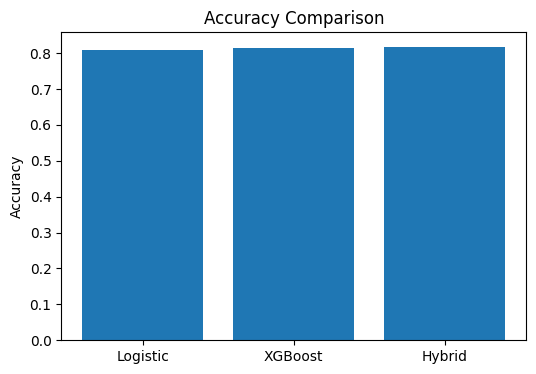

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


In [ ]:
# ============================================
# 1️⃣6️⃣ MULTI-INSTANCE EXPLANATION STABILITY
# ============================================

num_samples = 50  # you can increase to 100 later
agreement_scores = []

for idx in range(num_samples):

    # ---- SHAP Top 5 (XGBoost) ----
    shap_instance = shap_values_xgb[idx]

    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "Value": np.abs(shap_instance)
    }).sort_values(by="Value", ascending=False)

    shap_top5 = set(shap_df.head(5)["Feature"])

    # ---- LIME Top 5 ----
    lime_exp_instance = lime_explainer.explain_instance(
        X_test_df.iloc[idx].values,
        xgb_model.predict_proba,
        num_features=5
    )

    lime_features = [feat[0].split(' ')[0] for feat in lime_exp_instance.as_list()]
    lime_top5 = set(lime_features)

    # ---- Agreement ----
    overlap = shap_top5.intersection(lime_top5)
    agreement = len(overlap) / 5

    agreement_scores.append(agreement)

# Average stability score
avg_agreement = np.mean(agreement_scores) * 100

print("Average SHAP–LIME Agreement (%):", avg_agreement)


Average SHAP–LIME Agreement (%): 31.2


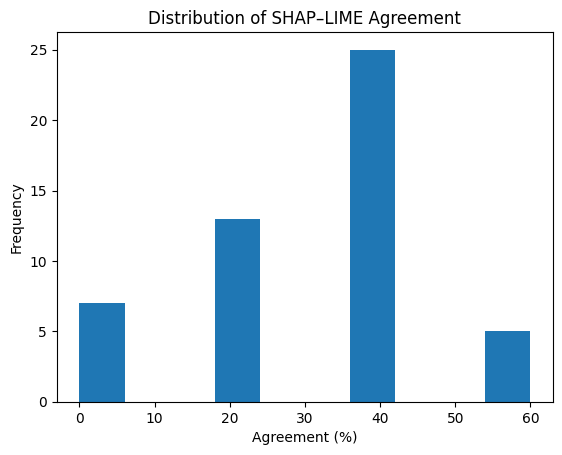

In [ ]:
plt.hist(np.array(agreement_scores)*100, bins=10)
plt.title("Distribution of SHAP–LIME Agreement")
plt.xlabel("Agreement (%)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# ============================================
# 1️⃣7️⃣ FAIRNESS ANALYSIS SETUP
# ============================================

# Convert test set back to DataFrame
test_df = pd.DataFrame(X_test, columns=feature_names)
test_df["Actual"] = y_test.values
test_df["Prediction"] = xgb_pred


In [ ]:
# ============================================
# FAIRNESS: SEX GROUP ANALYSIS
# ============================================

gender_fairness = test_df.groupby("SEX")["Prediction"].mean()

print("Default Prediction Rate by Gender:")
print(gender_fairness)


Default Prediction Rate by Gender:
SEX
-1.23695    0.133222
 0.80844    0.115620
Name: Prediction, dtype: float64


In [ ]:
dp_difference = abs(gender_fairness.iloc[0] - gender_fairness.iloc[1])

print("Demographic Parity Difference:", dp_difference)


Demographic Parity Difference: 0.01760252596617881


In [ ]:
from sklearn.metrics import confusion_matrix

def true_positive_rate(group):
    cm = confusion_matrix(group["Actual"], group["Prediction"])
    return cm[1,1] / (cm[1,0] + cm[1,1])

tpr_by_gender = test_df.groupby("SEX").apply(true_positive_rate)

print("True Positive Rate by Gender:")
print(tpr_by_gender)

eo_difference = abs(tpr_by_gender.iloc[0] - tpr_by_gender.iloc[1])
print("Equal Opportunity Difference:", eo_difference)


True Positive Rate by Gender:
SEX
-1.23695    0.356506
 0.80844    0.362924
dtype: float64
Equal Opportunity Difference: 0.006418043125154149


/tmp/ipython-input-2900940280.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tpr_by_gender = test_df.groupby("SEX").apply(true_positive_rate)


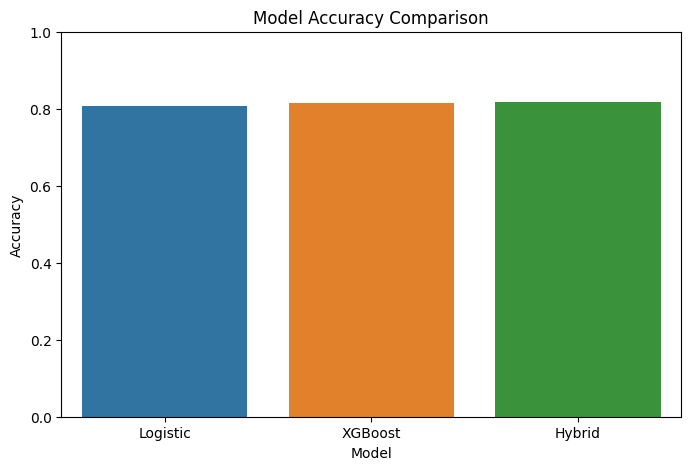

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    legend=False
)

plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()


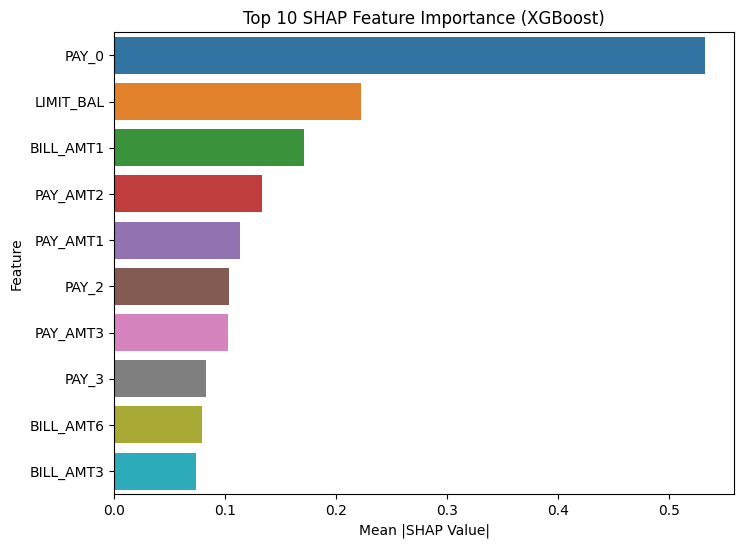

In [ ]:
top10 = xgb_importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top10["Importance"],
    y=top10["Feature"],
    hue=top10["Feature"],
    legend=False
)

plt.title("Top 10 SHAP Feature Importance (XGBoost)")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.show()


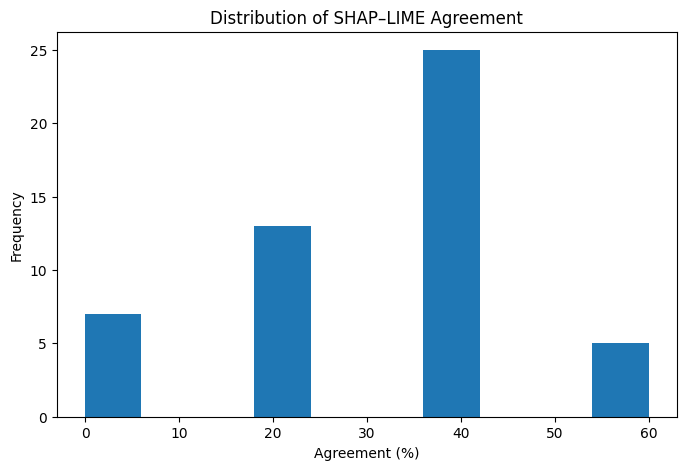

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(np.array(agreement_scores)*100, bins=10)

plt.title("Distribution of SHAP–LIME Agreement")
plt.xlabel("Agreement (%)")
plt.ylabel("Frequency")
plt.show()


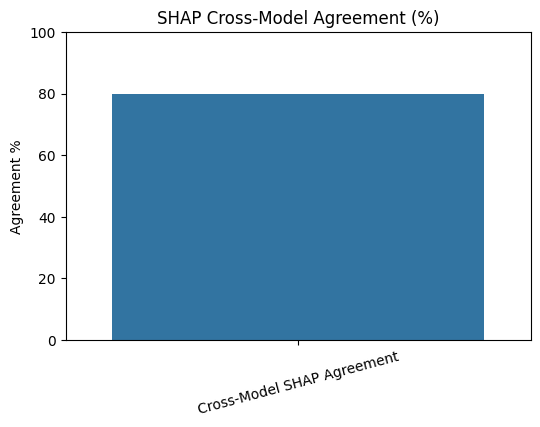

In [ ]:
labels = ["Cross-Model SHAP Agreement"]
values = [agreement_percentage]

plt.figure(figsize=(6,4))

sns.barplot(
    x=labels,
    y=values,
    hue=labels,
    legend=False
)

plt.ylim(0,100)
plt.title("SHAP Cross-Model Agreement (%)")
plt.ylabel("Agreement %")
plt.xticks(rotation=15)
plt.show()


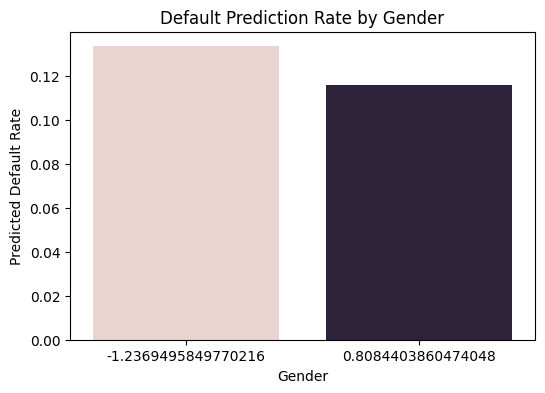

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_fairness.index,
    y=gender_fairness.values,
    hue=gender_fairness.index,
    legend=False
)

plt.title("Default Prediction Rate by Gender")
plt.ylabel("Predicted Default Rate")
plt.xlabel("Gender")
plt.show()


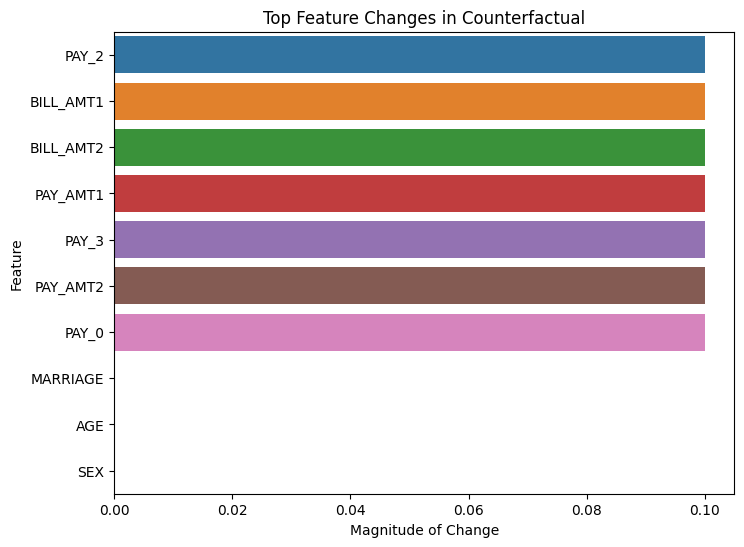

In [ ]:
diff = (cf_df - original_df).abs().T
diff.columns = ["Change"]

top_changes = diff.sort_values(by="Change", ascending=False).head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_changes["Change"],
    y=top_changes.index,
    hue=top_changes.index,
    legend=False
)

plt.title("Top Feature Changes in Counterfactual")
plt.xlabel("Magnitude of Change")
plt.ylabel("Feature")
plt.show()


In [ ]:
print("Logistic Accuracy:", accuracy_score(y_test, log_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("Hybrid Accuracy:", accuracy_score(y_test, hybrid_pred))


Logistic Accuracy: 0.8076666666666666
XGBoost Accuracy: 0.8155
Hybrid Accuracy: 0.8173333333333334


In [ ]:
from sklearn.metrics import roc_auc_score

print("Logistic AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))
print("XGBoost AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))
print("Hybrid AUC:", roc_auc_score(y_test, hybrid_probs))


Logistic AUC: 0.7076355036089734
XGBoost AUC: 0.7759734568431809
Hybrid AUC: 0.7669578367994819


In [51]:
# SHAP Summary Dot Plot (Distribution + Direction)

plt.figure()
shap.summary_plot(
    shap_values_xgb,
    pd.DataFrame(X_test, columns=feature_names),
    show=False
)

plt.tight_layout()
plt.savefig("shap_summary_dot.png", dpi=300)
plt.close()


In [52]:
# SHAP Summary Bar Plot (Global Importance)

plt.figure()
shap.summary_plot(
    shap_values_xgb,
    pd.DataFrame(X_test, columns=feature_names),
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=300)
plt.close()


In [53]:
# SHAP Force Plot for one instance

shap.initjs()

force_plot = shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[0],
    pd.DataFrame(X_test, columns=feature_names).iloc[0]
)

shap.save_html("shap_force_plot.html", force_plot)


In [54]:
# Find one default and one non-default case

default_idx = np.where(xgb_pred == 1)[0][0]
non_default_idx = np.where(xgb_pred == 0)[0][0]

print("Default Case Probability:",
      xgb_model.predict_proba([X_test[default_idx]])[0][1])

print("Non-Default Case Probability:",
      xgb_model.predict_proba([X_test[non_default_idx]])[0][1])


Default Case Probability: 0.8147488
Non-Default Case Probability: 0.13231619


In [55]:
force_default = shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[default_idx],
    pd.DataFrame(X_test, columns=feature_names).iloc[default_idx]
)

shap.save_html("shap_force_default.html", force_default)


In [56]:
force_non_default = shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[non_default_idx],
    pd.DataFrame(X_test, columns=feature_names).iloc[non_default_idx]
)

shap.save_html("shap_force_non_default.html", force_non_default)


In [57]:
# Counterfactual Example (Modify PAY_0)

original = X_test[default_idx].copy()
original_prob = xgb_model.predict_proba([original])[0][1]

feature_idx = list(feature_names).index("PAY_0")

counterfactual = original.copy()
counterfactual[feature_idx] -= 1

new_prob = xgb_model.predict_proba([counterfactual])[0][1]

print("Original Default Probability:", original_prob)
print("After Reducing PAY_0 by 1:", new_prob)


Original Default Probability: 0.8147488
After Reducing PAY_0 by 1: 0.77876514


In [58]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.65      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.79      6000



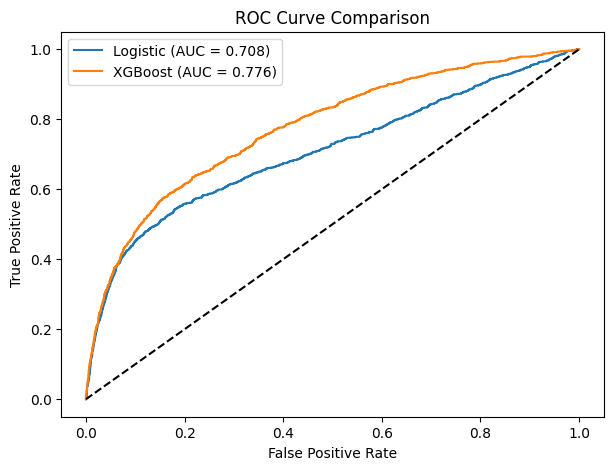

In [59]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities
log_probs = log_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# AUC
auc_log = roc_auc_score(y_test, log_probs)
auc_xgb = roc_auc_score(y_test, xgb_probs)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC = {auc_log:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_table = pd.DataFrame({
    "Model": ["Logistic", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1-score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, xgb_pred)
    ],
    "AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

print(comparison_table)


      Model  Accuracy  Precision    Recall  F1-score       AUC
0  Logistic  0.807667   0.686825  0.239638  0.355307  0.707636
1   XGBoost  0.815500   0.649457  0.360211  0.463403  0.775973


In [61]:
# Logistic SHAP importance
mean_shap_log = np.abs(shap_values_log).mean(axis=0)
log_importance = pd.DataFrame({
    "Feature": feature_names,
    "Logistic_SHAP": mean_shap_log
}).sort_values(by="Logistic_SHAP", ascending=False)

# XGBoost SHAP importance
mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "XGBoost_SHAP": mean_shap_xgb
}).sort_values(by="XGBoost_SHAP", ascending=False)

# Merge
shap_comparison = pd.merge(
    log_importance.head(10),
    xgb_importance.head(10),
    on="Feature",
    how="outer"
)

print(shap_comparison)


      Feature  Logistic_SHAP  XGBoost_SHAP
0   BILL_AMT1       0.214267      0.171006
1   BILL_AMT2       0.063097           NaN
2   BILL_AMT3            NaN      0.073312
3   BILL_AMT6            NaN      0.079067
4   EDUCATION       0.077172           NaN
5   LIMIT_BAL       0.110598      0.222160
6    MARRIAGE       0.070580           NaN
7       PAY_0       0.436606      0.531851
8       PAY_2       0.066048      0.102931
9       PAY_3       0.068150      0.082559
10   PAY_AMT1       0.089124      0.113135
11   PAY_AMT2       0.064786      0.133268
12   PAY_AMT3            NaN      0.102221


In [62]:
top_feature = xgb_importance.iloc[0]["Feature"]

print(f"The most influential feature according to XGBoost SHAP is: {top_feature}")
print("This indicates that repayment behavior strongly drives default prediction.")


The most influential feature according to XGBoost SHAP is: PAY_0
This indicates that repayment behavior strongly drives default prediction.


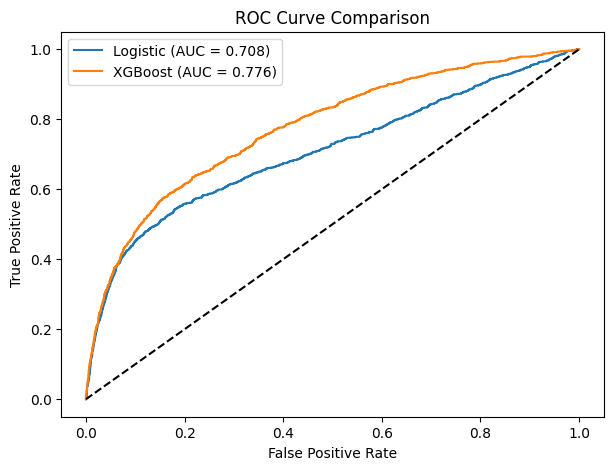

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities
log_probs = log_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# AUC
auc_log = roc_auc_score(y_test, log_probs)
auc_xgb = roc_auc_score(y_test, xgb_probs)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC = {auc_log:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_table = pd.DataFrame({
    "Model": ["Logistic", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1-score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, xgb_pred)
    ],
    "AUC": [
        auc_log,
        auc_xgb
    ]
})

comparison_table


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic,0.807667,0.686825,0.239638,0.355307,0.707636
1,XGBoost,0.815500,0.649457,0.360211,0.463403,0.775973


In [65]:
# Find one rejected applicant
rejected_idx = np.where(xgb_pred == 1)[0][0]

original = X_test[rejected_idx].copy()
original_prob = xgb_model.predict_proba([original])[0][1]

print("Original Default Probability:", original_prob)

# Increase credit limit and reduce repayment delay
cf = original.copy()

# Example: reduce PAY_0 (repayment delay improves)
pay0_idx = list(feature_names).index("PAY_0")
cf[pay0_idx] -= 1

# Example: increase LIMIT_BAL
limit_idx = list(feature_names).index("LIMIT_BAL")
cf[limit_idx] += 1

new_prob = xgb_model.predict_proba([cf])[0][1]

print("New Default Probability:", new_prob)

if new_prob < 0.5:
    print("Decision flipped to APPROVED")
else:
    print("Still REJECTED")


Original Default Probability: 0.8147488
New Default Probability: 0.52192867
Still REJECTED


In [66]:
# Top 5 XGBoost SHAP features
top5 = xgb_importance.head(5)

print("Top 5 Important Features:")
print(top5)

print("\nInterpretation:")
for feature in top5["Feature"]:
    print(f"- {feature} significantly influences default prediction.")


Top 5 Important Features:
      Feature  XGBoost_SHAP
5       PAY_0      0.531851
0   LIMIT_BAL      0.222160
11  BILL_AMT1      0.171006
18   PAY_AMT2      0.133268
17   PAY_AMT1      0.113135

Interpretation:
- PAY_0 significantly influences default prediction.
- LIMIT_BAL significantly influences default prediction.
- BILL_AMT1 significantly influences default prediction.
- PAY_AMT2 significantly influences default prediction.
- PAY_AMT1 significantly influences default prediction.


In [67]:
print("Prediction rate by SEX:")
print(test_df.groupby("SEX")["Prediction"].mean())


Prediction rate by SEX:
SEX
-1.23695    0.133222
 0.80844    0.115620
Name: Prediction, dtype: float64


Limitations:
- The dataset represents a specific financial population and may not generalize globally.
- Counterfactual modifications are synthetic and may not reflect real-world constraints.
- SHAP explanations depend on the underlying model behavior.
- Results are sensitive to chosen classification threshold (0.5).
